# **Practical Q3: Multiclass SVM on Iris**

### Import Libraries

In [1]:
# Improting needed libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



---


## Part (a) Baseline model: Linear SVM
### Load iris dataset and Train/Test Split (70/30)

In [2]:
# Load iris dataset and split (70/30) with stratification
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

### Baseline Linear SVM Pipeline

In [3]:
# Baseline model: Linear SVM on original 4D features
pipe_linear = Pipeline([
    ("scale", StandardScaler()),
    ("svc", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))
])

pipe_linear.fit(X_train, y_train)
y_pred_lin = pipe_linear.predict(X_test)

### Evaluation of Baseline Model

In [4]:
print("=== Baseline Linear SVM ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lin))
print("F1-weighted:", f1_score(y_test, y_pred_lin, average="weighted"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lin))
print("\nClassification report:\n",
      classification_report(y_test, y_pred_lin, digits=3))

=== Baseline Linear SVM ===
Accuracy: 0.9111111111111111
F1-weighted: 0.9107142857142857
Confusion matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      0.824     0.933     0.875        15
           2      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45





---

## Part (b) RBF SVM with PCA(2) + tuning


### Building the PCA(2) + RBF SVM Pipeline

In [5]:
# creating the needed pipeline
pipe_rbf = Pipeline([
    ("scale", StandardScaler()),
    ("pca2", PCA(n_components=2, random_state=RANDOM_STATE)),
    ("svc", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])

### Hyperparameter Grid + GridSearchCV

In [6]:
param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.1, 1.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

gs = GridSearchCV(
    pipe_rbf,
    param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1
)

gs.fit(X_train, y_train)

print("\nBest parameters (RBF + PCA2):", gs.best_params_)
print("Best CV accuracy:", gs.best_score_)


Best parameters (RBF + PCA2): {'svc__C': 1, 'svc__gamma': 1.0}
Best CV accuracy: 0.9142857142857143


### Evaluate the Final RBF Model on Test Set


In [7]:
# Evaluate tuned model
best_rbf = gs.best_estimator_
y_pred_rbf = best_rbf.predict(X_test)

print("\n=== Tuned RBF SVM (PCA 2D) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("F1-weighted:", f1_score(y_test, y_pred_rbf, average="weighted"))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_rbf))
print("\nClassification report:\n",
      classification_report(y_test, y_pred_rbf, digits=3))


=== Tuned RBF SVM (PCA 2D) ===
Accuracy: 0.9111111111111111
F1-weighted: 0.9107142857142857
Confusion matrix:
 [[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      0.824     0.933     0.875        15
           2      0.923     0.800     0.857        15

    accuracy                          0.911        45
   macro avg      0.916     0.911     0.911        45
weighted avg      0.916     0.911     0.911        45



### Compute PCA(2) Coordinates for Full Dataset

In [8]:
# Decision boundary in 2D PCA space
scaler = best_rbf.named_steps["scale"]
pca2   = best_rbf.named_steps["pca2"]
clf2   = best_rbf.named_steps["svc"]

X_2d = pca2.transform(scaler.transform(X.values))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


### Generate Grid and Predict for Decision Boundary
A mesh grid is created in the PCA(2) space, and the tuned classifier
predicts labels for each point to form the decision boundaries.

In [9]:
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf2.predict(grid).reshape(xx.shape)

### Final Decision Region Plot

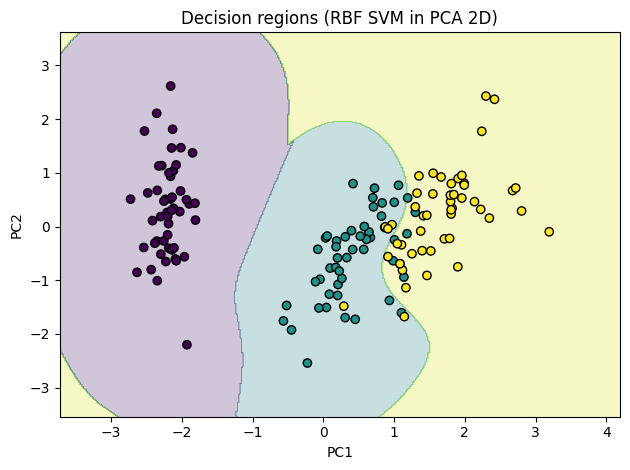

In [10]:
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, edgecolor="k")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Decision regions (RBF SVM in PCA 2D)")
plt.tight_layout()
plt.show()